In [3]:
import geopandas as gpd
import osmnx as ox
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt

print("Окэй")

Окэй


Скачана граница Московской области
Площадь: 139,416 км²


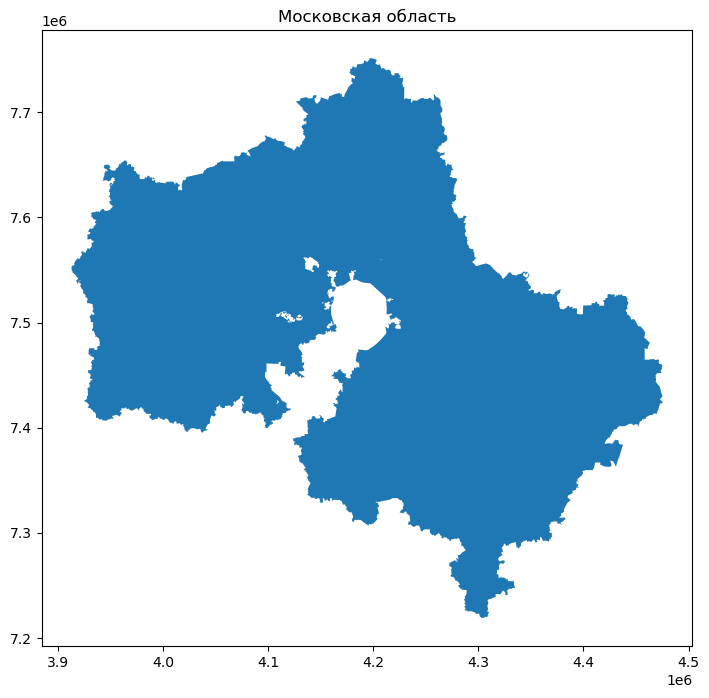

In [6]:
mo = ox.geocode_to_gdf("Moscow Oblast, Russia")
mo = mo.to_crs(epsg=3857)
mo.to_file("../data/processed/border_mo.gpkg", driver="GPKG")

area_km2 = mo.geometry.area.sum() / 1e6
print(f"Скачана граница Московской области")
print(f"Площадь: {area_km2:,.0f} км²")

mo.plot(figsize=(10, 8))
plt.title("Московская область")
plt.show()

In [5]:
import os
os.makedirs("../data/processed", exist_ok=True)
print("создалась")

создалась


In [10]:
def build_grid(border, cell_size=1000):
    minx, miny, maxx, maxy = border.total_bounds
    minx = np.floor(minx / cell_size) * cell_size
    miny = np.floor(miny / cell_size) * cell_size
    maxx = np.ceil(maxx / cell_size) * cell_size
    maxy = np.ceil(maxy / cell_size) * cell_size
    
    cells = []
    for x in np.arange(minx, maxx, cell_size):
        for y in np.arange(miny, maxy, cell_size):
            cells.append(box(x, y, x + cell_size, y + cell_size))
    
    grid = gpd.GeoDataFrame({'geometry': cells}, crs=border.crs)
    grid = gpd.overlay(grid, border[['geometry']], how='intersection')
    grid['cell_id'] = range(len(grid))
    grid['area_km2'] = grid.geometry.area / 1e6
    return grid

grid_mo = build_grid(mo)

grid_mo.to_file("../data/processed/grid_mo.gpkg", driver="GPKG")
print("Сетка сохранена")

Сетка сохранена


In [11]:
print(f"Всего ячеек: {len(grid_mo):,}")
print(f"Средняя площадь ячейки: {grid_mo['area_km2'].mean():.3f} км²")
print(f"Самая маленькая ячейка: {grid_mo['area_km2'].min():.3f} км²")
print(f"Самая большая ячейка: {grid_mo['area_km2'].max():.3f} км²")
print(f"Суммарная площадь: {grid_mo['area_km2'].sum():,.0f} км²")

Всего ячеек: 141,967
Средняя площадь ячейки: 0.982 км²
Самая маленькая ячейка: 0.000 км²
Самая большая ячейка: 1.000 км²
Суммарная площадь: 139,416 км²


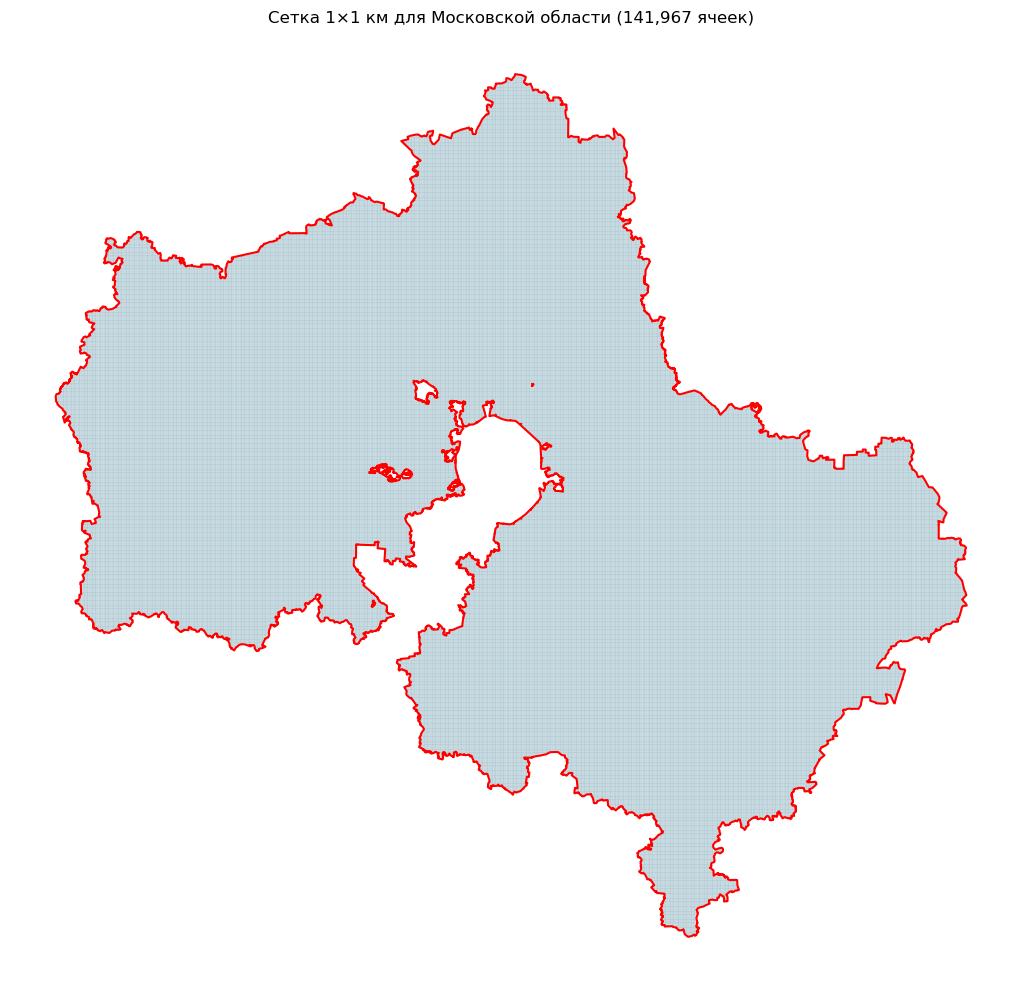

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))

mo.boundary.plot(ax=ax, color='red', linewidth=1.5)

grid_mo.plot(ax=ax, edgecolor='black', linewidth=0.05, facecolor='lightblue', alpha=0.5)

ax.set_title(f"Сетка 1×1 км для Московской области ({len(grid_mo):,} ячеек)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [13]:
from shapely.geometry import Point

cities_wgs84 = {
    'Москва': (37.6173, 55.7558),
    'Балашиха': (37.9384, 55.7964),
    'Подольск': (37.5447, 55.4297),
    'Химки': (37.4448, 55.8970),
    'Мытищи': (37.7295, 55.9117),
    'Люберцы': (37.9534, 55.6760),
    'Электросталь': (38.4445, 55.7847),
    'Коломна': (38.7544, 55.0794),
    'Серпухов': (37.4216, 54.9156),
}

cities_gdf = gpd.GeoDataFrame(
    {'city': list(cities_wgs84.keys())},
    geometry=[Point(lon, lat) for lon, lat in cities_wgs84.values()],
    crs='EPSG:4326'
).to_crs(epsg=3857)

print(f"Города загружены: {len(cities_gdf)}")
cities_gdf

Города загружены: 9


,city,geometry
0,Москва,POINT (4187538.681 7509955.142)
1,Балашиха,POINT (4223283.37 7517990.961)
2,Подольск,POINT (4179456.886 7445712.741)
3,Химки,POINT (4168336.069 7537938.534)
4,Мытищи,POINT (4200028.728 7540857.667)
5,Люберцы,POINT (4224953.162 7494184.949)
6,Электросталь,POINT (4279622.164 7515674.361)
7,Коломна,POINT (4314120.074 7377291.308)
8,Серпухов,POINT (4165753.457 7345502.994)


In [14]:
grid_mo['centroid'] = grid_mo.geometry.centroid

print(f"Центроидов: {len(grid_mo)}")
grid_mo[['cell_id', 'area_km2', 'centroid']].head()

Центроидов: 141967


,cell_id,area_km2,centroid
0,0,0.058086,POINT (3912888.345 7549882.916)
1,1,0.076979,POINT (3912939.842 7550373.068)
2,2,0.116458,POINT (3912939.358 7551558.765)
3,3,0.179033,POINT (3912908.626 7552494.021)
4,4,0.013256,POINT (3912965.773 7553086.066)


In [15]:
moscow_point = cities_gdf[cities_gdf['city'] == 'Москва'].geometry.iloc[0]
grid_mo['dist_to_moscow_km'] = grid_mo['centroid'].distance(moscow_point) / 1000

print(f"Расстояние до Москвы:")
print(f"  Минимум: {grid_mo['dist_to_moscow_km'].min():.1f} км")
print(f"  Максимум: {grid_mo['dist_to_moscow_km'].max():.1f} км")
print(f"  Среднее: {grid_mo['dist_to_moscow_km'].mean():.1f} км")

Расстояние до Москвы:
  Минимум: 25.3 км
  Максимум: 314.2 км
  Среднее: 163.3 км


In [16]:
def min_distance_to_cities(point, cities):
    return min(point.distance(c) for c in cities.geometry)

grid_mo['dist_to_city_km'] = grid_mo['centroid'].apply(
    lambda p: min_distance_to_cities(p, cities_gdf) / 1000
)

print(f"Расстояние до ближайшего города:")
print(f"  Минимум: {grid_mo['dist_to_city_km'].min():.1f} км")
print(f"  Максимум: {grid_mo['dist_to_city_km'].max():.1f} км")
print(f"  Среднее: {grid_mo['dist_to_city_km'].mean():.1f} км")

Расстояние до ближайшего города:
  Минимум: 0.2 км
  Максимум: 255.8 км
  Среднее: 99.4 км


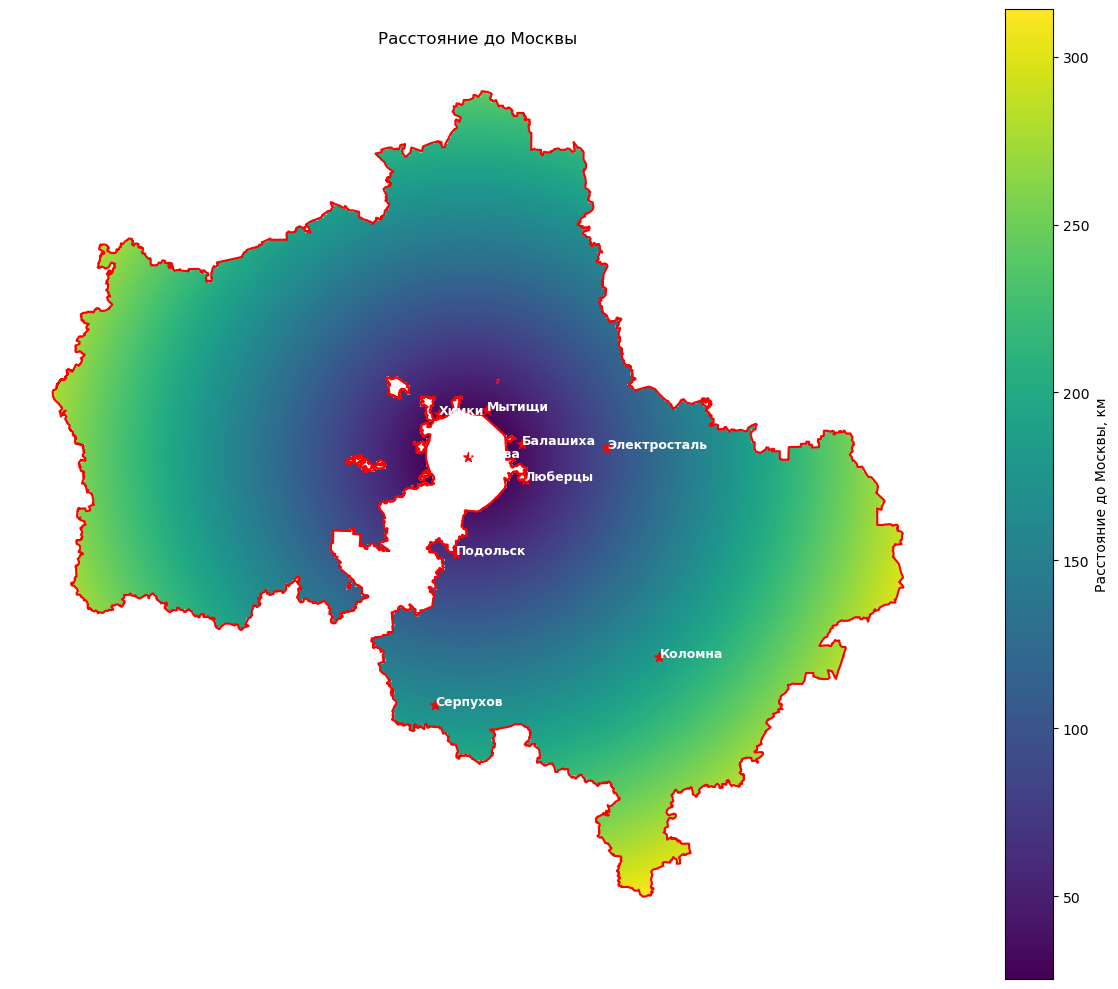

In [17]:
fig, ax = plt.subplots(figsize=(12, 10))

grid_mo.plot(column='dist_to_moscow_km', ax=ax, cmap='viridis', 
             legend=True, legend_kwds={'label': 'Расстояние до Москвы, км'})

cities_gdf.plot(ax=ax, color='red', markersize=50, marker='*')
for idx, row in cities_gdf.iterrows():
    ax.annotate(row['city'], (row.geometry.x, row.geometry.y), 
                fontsize=9, color='white', weight='bold')

mo.boundary.plot(ax=ax, color='red', linewidth=1.5)

ax.set_title("Расстояние до Москвы")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [19]:
grid_mo['city_weight'] = 1 / (grid_mo['dist_to_city_km'] + 1)
grid_mo['moscow_weight'] = 1 / (grid_mo['dist_to_moscow_km'] + 1)
print(grid_mo[['city_weight', 'moscow_weight']].describe())

         city_weight  moscow_weight
count  141967.000000  141967.000000
mean        0.017873       0.007504
std         0.024464       0.004440
min         0.003893       0.003172
25%         0.006938       0.004705
50%         0.011327       0.006080
75%         0.019366       0.008530
max         0.824471       0.038046


In [21]:
# Региональное значение отгрузки для Моск области
X_region_otgr = 209.0  # млрд руб

# BASELINE
grid_mo['baseline_otgr'] = X_region_otgr * grid_mo['area_km2'] / grid_mo['area_km2'].sum()

print(f"BASELINE для отгрузки:")
print(f"  Сумма: {grid_mo['baseline_otgr'].sum():.2f} млрд руб")
print(f"  Минимум: {grid_mo['baseline_otgr'].min():.6f}")
print(f"  Максимум: {grid_mo['baseline_otgr'].max():.6f}")
print(f"  Все ячейки получают примерно одинаковое значение. это и есть baseline")

BASELINE для отгрузки:
  Сумма: 209.00 млрд руб
  Минимум: 0.000000
  Максимум: 0.001499
  Все ячейки получают примерно одинаковое значение. это и есть baseline


In [22]:
# вес ячейки = комбинация близости к Москве и близости к городам
grid_mo['weight'] = (
    0.7 * grid_mo['moscow_weight'] + 
    0.3 * grid_mo['city_weight']
)

grid_mo['method_otgr'] = X_region_otgr * grid_mo['weight'] / grid_mo['weight'].sum()

print(f"МЕТОД для отгрузки:")
print(f"  Сумма: {grid_mo['method_otgr'].sum():.2f} млрд руб")
print(f"  Минимум: {grid_mo['method_otgr'].min():.6f}")
print(f"  Максимум: {grid_mo['method_otgr'].max():.6f}")
print(f"  Разница макс/мин: {grid_mo['method_otgr'].max() / grid_mo['method_otgr'].min():.0f}x")

МЕТОД для отгрузки:
  Сумма: 209.00 млрд руб
  Минимум: 0.000510
  Максимум: 0.035658
  Разница макс/мин: 70x


In [25]:
import os
os.makedirs("../results", exist_ok=True)
print("создана")

создана


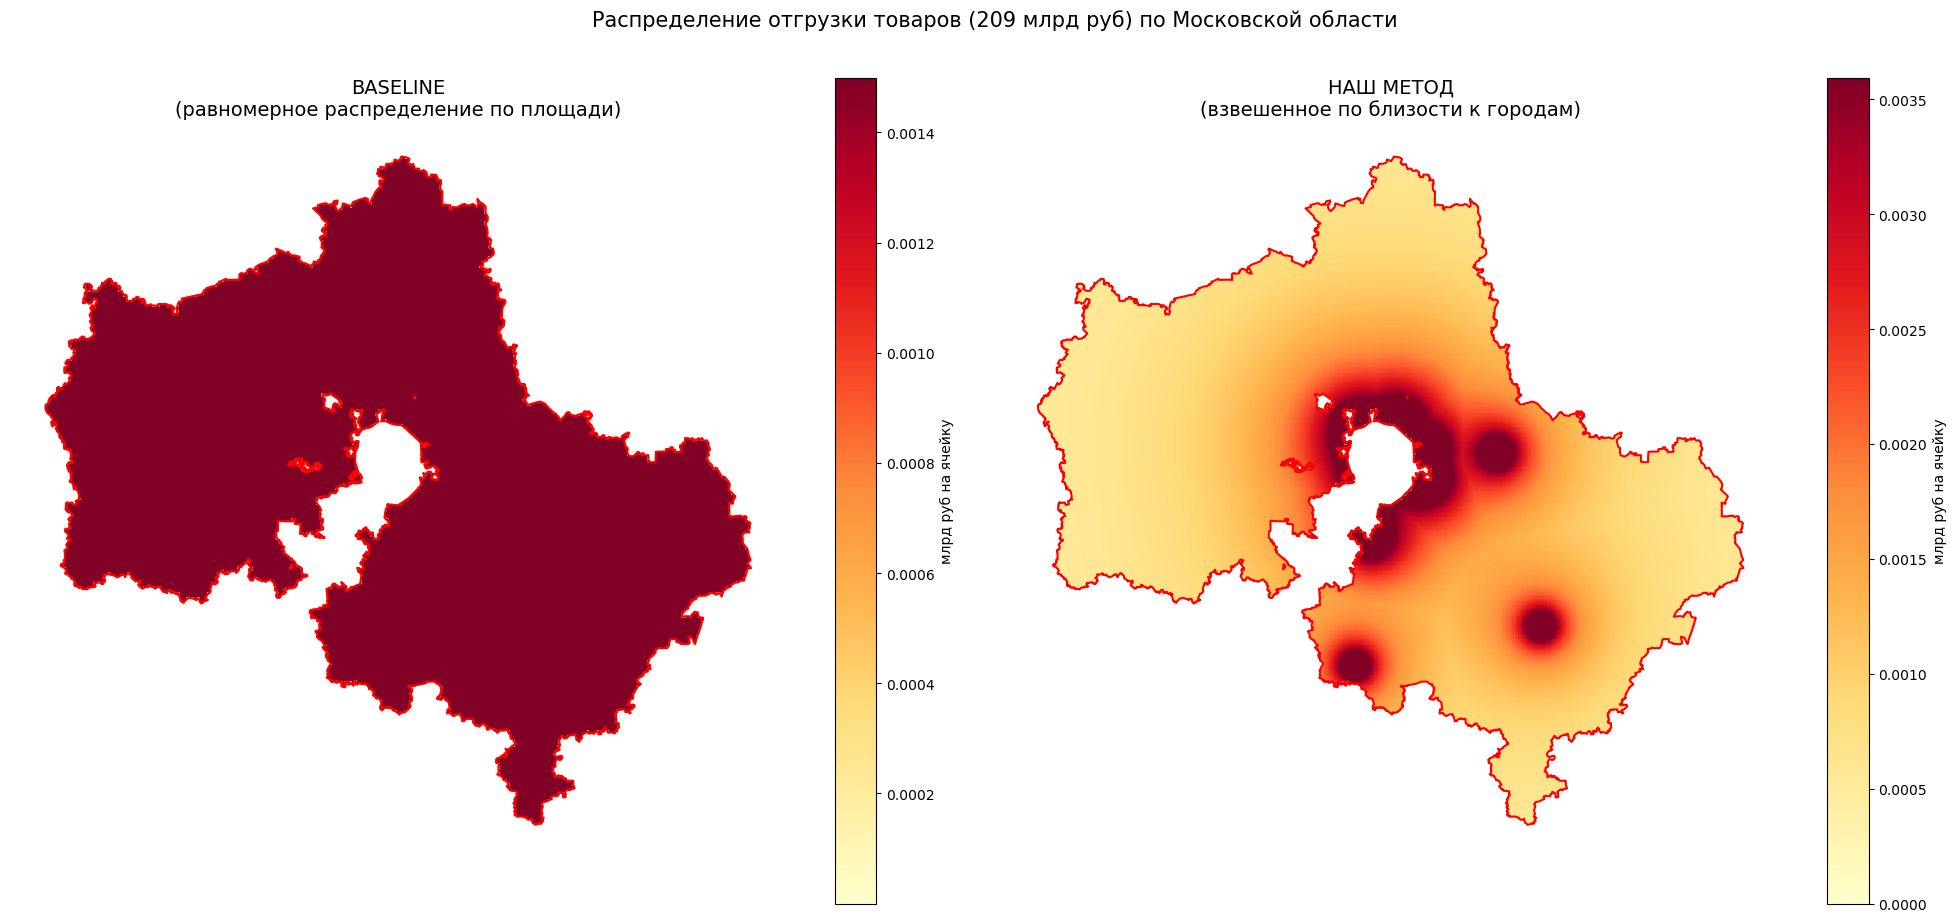

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# BASELINE
grid_mo.plot(column='baseline_otgr', ax=axes[0], cmap='YlOrRd', legend=True,
             legend_kwds={'label': 'млрд руб на ячейку'})
mo.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title('BASELINE\n(равномерное распределение по площади)', fontsize=14)
axes[0].set_axis_off()

# НАШ МЕТОД - используем log-цветовую шкалу через vmax (отрезаем верхние выбросы)
import numpy as np
vmax = grid_mo['method_otgr'].quantile(0.95)  

grid_mo.plot(column='method_otgr', ax=axes[1], cmap='YlOrRd', legend=True,
             vmin=0, vmax=vmax,
             legend_kwds={'label': 'млрд руб на ячейку'})
mo.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('НАШ МЕТОД\n(взвешенное по близости к городам)', fontsize=14)
axes[1].set_axis_off()

plt.suptitle('Распределение отгрузки товаров (209 млрд руб) по Московской области', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_mo_shipping.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
import numpy as np

def gini(values):
    sorted_v = np.sort(values)
    n = len(values)
    cumsum = np.cumsum(sorted_v)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

print("=== Сравнение с baseline ===\n")

print(f"Сумма baseline: {grid_mo['baseline_otgr'].sum():.2f}")
print(f"Сумма метода:   {grid_mo['method_otgr'].sum():.2f}")
print(f"Ожидаемое:      209.0\n")

gini_b = gini(grid_mo['baseline_otgr'].values)
gini_m = gini(grid_mo['method_otgr'].values)
print(f"Джини baseline: {gini_b:.4f}")
print(f"Джини метода:   {gini_m:.4f}\n")

top10_pct = int(len(grid_mo) * 0.1)
top10_b = grid_mo['baseline_otgr'].nlargest(top10_pct).sum() / grid_mo['baseline_otgr'].sum()
top10_m = grid_mo['method_otgr'].nlargest(top10_pct).sum() / grid_mo['method_otgr'].sum()
print(f"Доля в топ-10% ячеек:")
print(f"  Baseline: {top10_b:.1%}")
print(f"  Метод:    {top10_m:.1%}")

=== Сравнение с baseline ===

Сумма baseline: 209.00
Сумма метода:   209.00
Ожидаемое:      209.0

Джини baseline: 0.0179
Джини метода:   0.3487

Доля в топ-10% ячеек:
  Baseline: 10.2%
  Метод:    29.5%


In [28]:
X_region_shx = 85692.0  # млн руб

grid_mo['baseline_shx'] = X_region_shx * grid_mo['area_km2'] / grid_mo['area_km2'].sum()

grid_mo['shx_weight'] = grid_mo['dist_to_city_km'] / (grid_mo['dist_to_moscow_km'] + 1)

grid_mo['method_shx'] = X_region_shx * grid_mo['shx_weight'] / grid_mo['shx_weight'].sum()

print(f"Сумма baseline: {grid_mo['baseline_shx'].sum():.2f}")
print(f"Сумма метода:   {grid_mo['method_shx'].sum():.2f}")
print(f"Ожидаемое:      85692.0")

Сумма baseline: 85692.00
Сумма метода:   85692.00
Ожидаемое:      85692.0


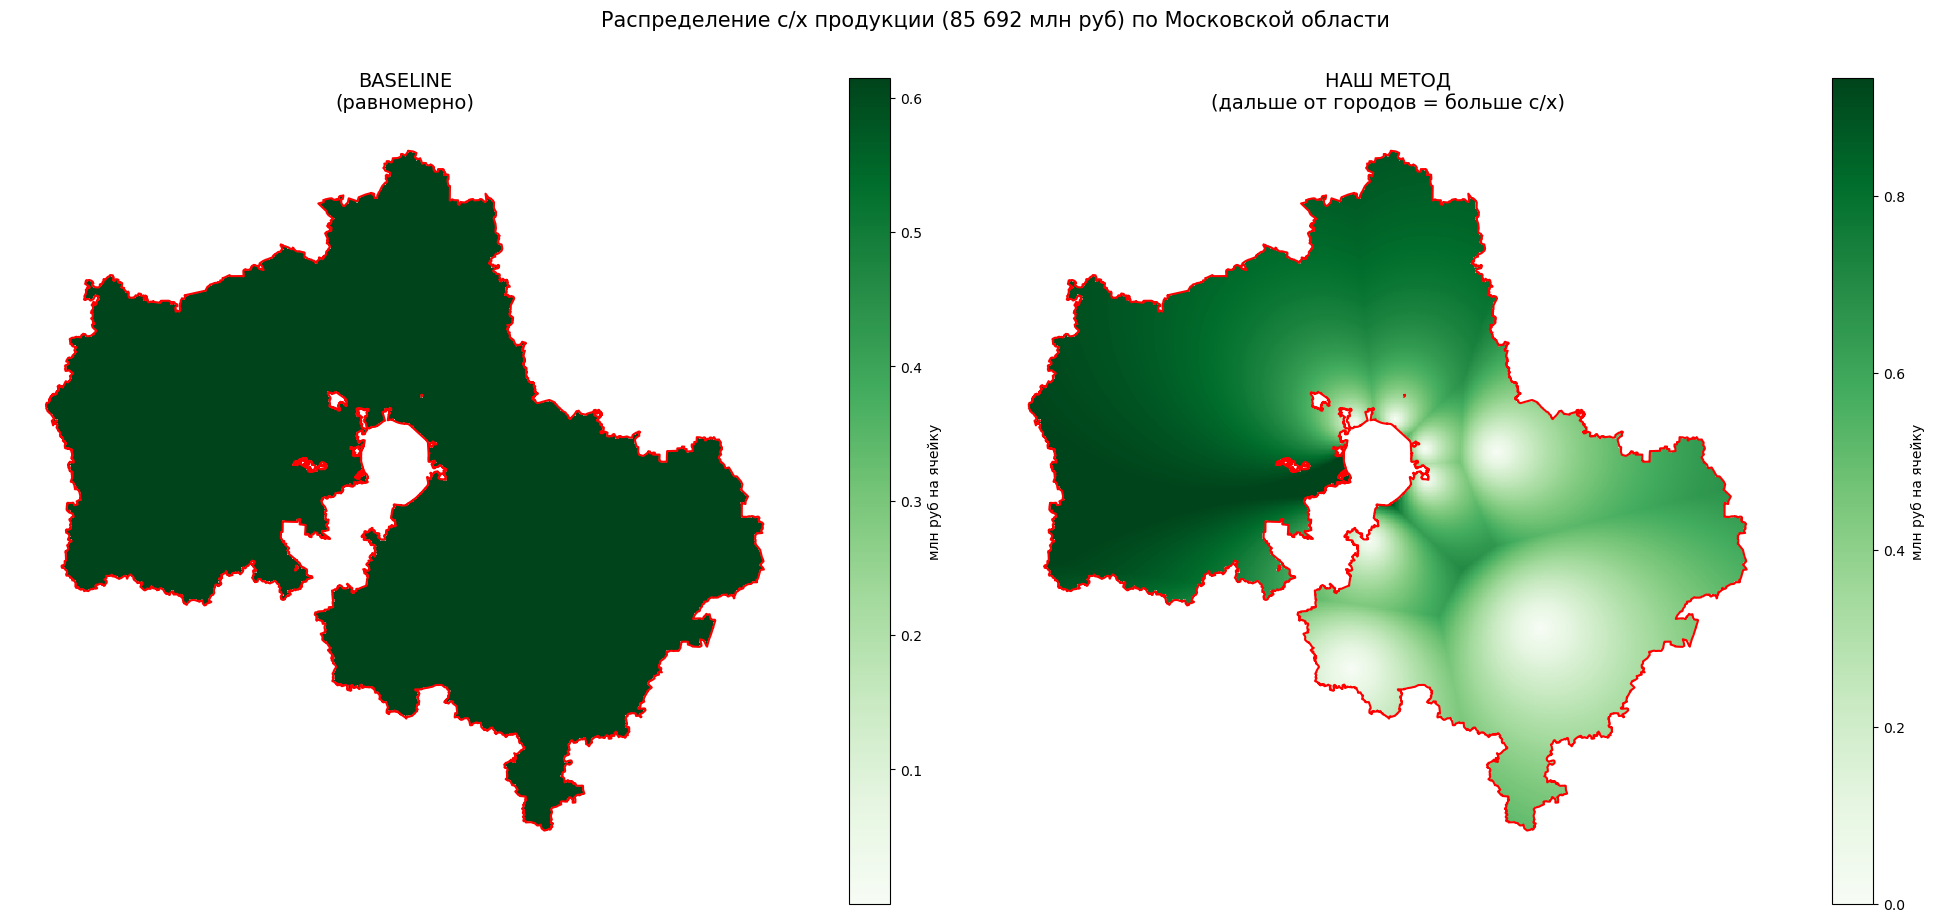

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

grid_mo.plot(column='baseline_shx', ax=axes[0], cmap='Greens', legend=True,
             legend_kwds={'label': 'млн руб на ячейку'})
mo.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title('BASELINE\n(равномерно)', fontsize=14)
axes[0].set_axis_off()

vmax = grid_mo['method_shx'].quantile(0.95)
grid_mo.plot(column='method_shx', ax=axes[1], cmap='Greens', legend=True,
             vmin=0, vmax=vmax,
             legend_kwds={'label': 'млн руб на ячейку'})
mo.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('НАШ МЕТОД\n(дальше от городов = больше с/х)', fontsize=14)
axes[1].set_axis_off()

plt.suptitle('Распределение с/х продукции (85 692 млн руб) по Московской области', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_mo_agriculture.png', dpi=150, bbox_inches='tight')
plt.show()